# Impurity radiation investigation: single model running of Process
Run an individual model of Process to investigate impurity radiation. For high W and He impurities (upper bounds of uncertainties), it is suspected that the power conducted to the divertor (`pdivt`) is unphysical.

In [190]:
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt

## Set up
Run a once-through large tokamak to initialise values.

In [191]:
process.fortran.physics_variables.pdivt

array(0.001)

In [192]:
# TODO Apparently need to run once-through?
# single_run = SingleRun("large_tokamak_IN.DAT")
single_run = SingleRun("large_tokamak_once_through_IN.DAT")
single_run.run()

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag : v3.1.0-301-gf700a31cc
 Git Branch : main
 Date : 24/02/2025 UTC
 Time : 16:07
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/impurities
 Input : /home/jon/code/notebooks/impurities/large_tokamak_once_through_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 *********************************************************************************

/home/jon/code/process/process/init.py:39: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process()


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowan

In [193]:
# Kernel can crash when running physics without correctly initialised values.
# Doesn't crash after running a once-through
# Print initial values of interest
print(f"fimp(14) = {process.fortran.impurity_radiation_module.fimp[13]:.3e}")
print(f"p_plasma_rad_mw = {process.fortran.physics_variables.p_plasma_rad_mw:.3e}")
print(f"pdivt = {process.fortran.physics_variables.pdivt:.3e}")

fimp(14) = 5.000e-06
p_plasma_rad_mw = 2.191e+02
pdivt = 1.699e+02


Now try changing fimp(14) to get a change in pdivt.

In [194]:
process.fortran.impurity_radiation_module.impurity_arr_frac[13] = 1.0e-5
single_run.models.physics.physics()

print(
    f"fimp(14) = {process.fortran.impurity_radiation_module.impurity_arr_frac[13]:.3e}"
)
print(f"p_plasma_rad_mw = {process.fortran.physics_variables.p_plasma_rad_mw:.3e}")
print(f"pdivt = {process.fortran.physics_variables.pdivt:.3e}")

fimp(14) = 1.000e-05
p_plasma_rad_mw = 2.257e+02
pdivt = 1.632e+02


Can now control p_plasma_rad_mw and pdivt with fimp(14) (W impurity) fraction.

See notes for this convoluted setting of impurity fraction.

## Study: parameter scan of W impurity fraction with nominal and high He fractions
Check values of impurity radiation power, divetor power and constraint 15 (L-H threshold constraint).

In [195]:
def run_impurities(w_imp_fracs):
    """Calculate responses to W impurities."""
    n = w_imp_fracs.shape[0]
    p_plasma_rad_mw = np.empty(n)
    pdivt = np.empty(n)
    p_l_h_threshold_mw = np.empty(n)
    con15 = np.empty(n)

    for i, imp_frac in enumerate(w_imp_fracs):
        process.fortran.impurity_radiation_module.impurity_arr_frac[13] = imp_frac
        single_run.models.physics.physics()

        # Evaluate constraint equation 15 (L-H threshold constraint)
        con15_value, _, _, _, _ = process.fortran.constraints.constraint_eqn_015()

        # Need to copy values
        p_plasma_rad_mw[i] = process.fortran.physics_variables.p_plasma_rad_mw.item()
        pdivt[i] = process.fortran.physics_variables.pdivt.item()
        p_l_h_threshold_mw[i] = (
            process.fortran.physics_variables.p_l_h_threshold_mw.item()
        )
        con15[i] = -con15_value

    return p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15

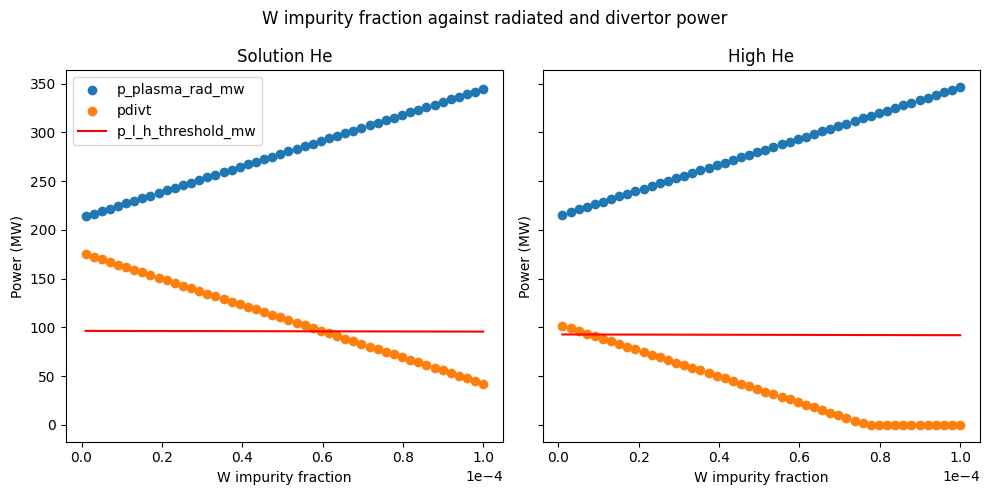

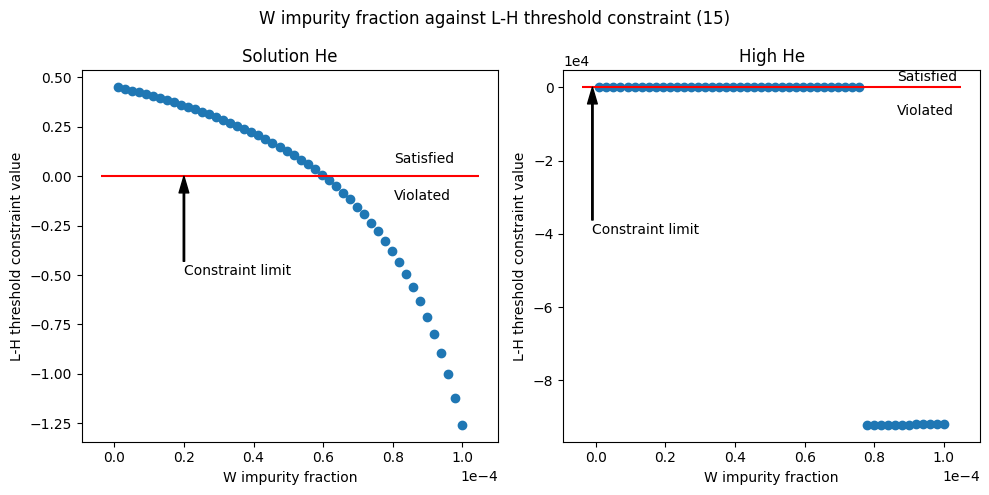

In [196]:
w_imp_fracs = np.linspace(1.0e-6, 1.0e-4, 50)
# He frac at solution (was optimisation parameter)
HE_FRAC_SOLUTION = 0.060238763988650204
HE_FRAC_HIGH = 0.115
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_SOLUTION
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs)
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_HIGH
p_plasma_rad_mw_he, pdivt_he, p_l_h_threshold_mw_he, con15_he = run_impurities(
    w_imp_fracs
)

fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# Normal He plot
ax[0].scatter(w_imp_fracs, p_plasma_rad_mw, label="p_plasma_rad_mw")
ax[0].scatter(w_imp_fracs, pdivt, label="pdivt")
ax[0].plot(w_imp_fracs, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)")
ax[0].set_title("Solution He")
ax[0].legend()
# High He plot
ax[1].scatter(w_imp_fracs, p_plasma_rad_mw_he, label="p_plasma_rad_mw")
ax[1].scatter(w_imp_fracs, pdivt_he, label="pdivt")
ax[1].plot(w_imp_fracs, p_l_h_threshold_mw_he, "r", label="p_l_h_threshold_mw")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("Power (MW)")
ax[1].set_title("High He")

fig.suptitle("W impurity fraction against radiated and divertor power")
fig.tight_layout()

# Constraint plots
fig, ax = plt.subplots(ncols=2)
fig.set_figwidth(10)
fig.set_figheight(5)
# W plot
ax[0].scatter(w_imp_fracs, con15, label="con15")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("Solution He")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("L-H threshold constraint value")
ax[0].hlines(0.0, xmin=ax[0].get_xlim()[0], xmax=ax[0].get_xlim()[1], colors="r")
# He plot
ax[1].scatter(w_imp_fracs, con15_he, label="con15")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax[1].set_title("High He")
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("L-H threshold constraint value")
ax[1].hlines(0.0, xmin=ax[1].get_xlim()[0], xmax=ax[1].get_xlim()[1], colors="r")

# Annotations
ax[0].annotate("Satisfied", (0.75, 0.75), xycoords="axes fraction")
ax[0].annotate("Violated", (0.75, 0.65), xycoords="axes fraction")
ax[0].annotate(
    "Constraint limit",
    xy=(0.2e-4, 0),
    xytext=(0.2e-4, -0.5),
    arrowprops=dict(facecolor="black", width=1, headwidth=7),
)
ax[1].annotate("Satisfied", (0.8, 0.97), xycoords="axes fraction")
ax[1].annotate("Violated", (0.8, 0.88), xycoords="axes fraction")
ax[1].annotate(
    "Constraint limit",
    xy=(-0.01e-4, 0),
    xytext=(-0.01e-4, -4e4),
    arrowprops=dict(facecolor="black", width=1, headwidth=7),
)
fig.suptitle("W impurity fraction against L-H threshold constraint (15)")
fig.tight_layout()

- Solution He, pdivt: linear pdivt, no surprises, pdivt dips below p_l_h_threshold_mw at higher values of W impurity due to increasing radiated power
- Solution He, L-H constraint: constraint becomes violated, but isn't too extreme
- High He, pdivt: radiated power is unchanged, but pdivt is coerced to > 0
- High He, L-H constraint: constraint is extremely violated and discontinuous

Is this evidence of suspected pdivt going negative? pdivt is being coerced to be positive. Extreme constraint violation with a discontinuity is a problem.

## Why this behaviour?
pdivt and p_plasma_rad_mw are the responses of interest. Need to understand why they vary as they do.

With higher He, p_plasma_rad_mw strangely stays constant, yet pdivt drops markedly, translated down by ~75 MW. p_l_h_threshold_mw drops very slightly too.

### Trace pdivt calculation
`physics_variables.pdivt` calculated in `physics.py`.

```py
physics_variables.pdivt = (
    physics_variables.f_alpha_plasma * physics_variables.alpha_power_total
    + physics_variables.non_alpha_charged_power
    + pinj
    + physics_variables.p_plasma_ohmic_mw
    - physics_variables.p_plasma_rad_mw
)
```
Only -ve is `physics_variables.p_plasma_rad_mw`. Either alpha (e.g. He) fractions/powers aren't being updated properly (not running all models/optimising to balance constraints), or the plasma radiation is too high (greater than plasma power), resulting in negative pdivt. Negative pdivt can be correct, however: more radiated power than injected and fusion powers.

`p_plasma_rad_mw` changes with W fraction, but doesn't change with He fraction. So what is He fraction changing in the pdivt calculation?

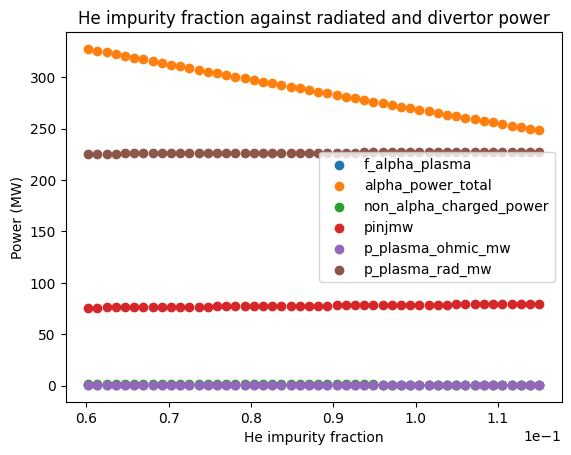

In [197]:
def run_impurities_he(he_imp_fracs):
    """Calculate responses to W impurities."""
    n = he_imp_fracs.shape[0]
    f_alpha_plasma = np.empty(n)
    alpha_power_total = np.empty(n)
    non_alpha_charged_power = np.empty(n)
    pinjmw = np.empty(n)
    p_plasma_ohmic_mw = np.empty(n)
    p_plasma_rad_mw = np.empty(n)

    for i, imp_frac in enumerate(he_imp_fracs):
        process.fortran.physics_variables.f_nd_alpha_electron = imp_frac
        single_run.models.physics.physics()

        f_alpha_plasma[i] = process.fortran.physics_variables.f_alpha_plasma.item()
        alpha_power_total[i] = (
            process.fortran.physics_variables.alpha_power_total.item()
        )
        non_alpha_charged_power[i] = (
            process.fortran.physics_variables.non_alpha_charged_power
        )
        pinjmw[i] = process.fortran.current_drive_variables.pinjmw
        p_plasma_ohmic_mw[i] = process.fortran.physics_variables.p_plasma_ohmic_mw
        p_plasma_rad_mw[i] = process.fortran.physics_variables.p_plasma_rad_mw

    return (
        f_alpha_plasma,
        alpha_power_total,
        non_alpha_charged_power,
        pinjmw,
        p_plasma_ohmic_mw,
        p_plasma_rad_mw,
    )


# Constant W fraction
process.fortran.impurity_radiation_module.impurity_arr_frac[13] = 1.0e-5
he_imp_fracs = np.linspace(HE_FRAC_SOLUTION, HE_FRAC_HIGH, 50)
(
    f_alpha_plasma,
    alpha_power_total,
    non_alpha_charged_power,
    pinjmw,
    p_plasma_ohmic_mw,
    p_plasma_rad_mw,
) = run_impurities_he(he_imp_fracs)

fig, ax = plt.subplots()
ax.scatter(he_imp_fracs, f_alpha_plasma, label="f_alpha_plasma")
ax.scatter(he_imp_fracs, alpha_power_total, label="alpha_power_total")
ax.scatter(he_imp_fracs, non_alpha_charged_power, label="non_alpha_charged_power")
ax.scatter(he_imp_fracs, pinjmw, label="pinjmw")
ax.scatter(he_imp_fracs, p_plasma_ohmic_mw, label="p_plasma_ohmic_mw")
ax.scatter(he_imp_fracs, p_plasma_rad_mw, label="p_plasma_rad_mw")
# ax.plot(w_imp_fracs, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.set_title("He impurity fraction against radiated and divertor power")
ax.set_xlabel("He impurity fraction")
ax.set_ylabel("Power (MW)")
ax.legend()

The 75 MW drop in pdivt is due to the drop in `alpha_power_total` due to increased He fraction. `f_nd_alpha_electron` (being varied here) is used in current_drive.py and physics.py. It's driving the `pdivt` response via `alpha_power_total`.

Increasing He fraction causes the alpha power to drop, and therefore pdivt to drop. Increasing W fraction causes radiated power to increase, and therefore pdivt to drop too. Both increases in impurity fraction cause pdivt to drop, but through different mechanisms. Are both high impurities required for this "zero pdivt" effect?

## Try extremely high W only: same effect?

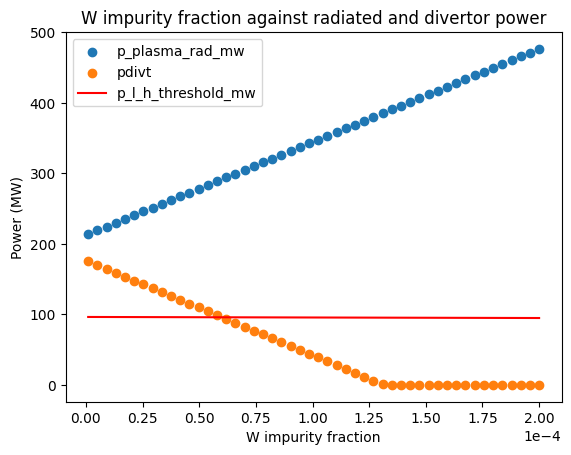

In [198]:
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_SOLUTION
w_imp_fracs_high = np.linspace(1.0e-6, 2.0e-4, 50)
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs_high)

fig, ax = plt.subplots()
ax.scatter(w_imp_fracs_high, p_plasma_rad_mw, label="p_plasma_rad_mw")
ax.scatter(w_imp_fracs_high, pdivt, label="pdivt")
ax.plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.set_title("W impurity fraction against radiated and divertor power")
ax.set_xlabel("W impurity fraction")
ax.set_ylabel("Power (MW)")
ax.legend()

Exactly same effect occurs with just very high W fraction: pdivt appears to try to go negative, but is coerced to be positive.

## Try Chris's plots

In [199]:
def run_impurities_tau_alpha(w_imp_fracs):
    """Calculate responses to W impurities."""
    n = w_imp_fracs.shape[0]
    t_alpha_confinement = np.empty(n)
    pdivt = np.empty(n)

    for i, imp_frac in enumerate(w_imp_fracs):
        process.fortran.impurity_radiation_module.impurity_arr_frac[13] = imp_frac
        single_run.models.physics.physics()

        t_alpha_confinement[i] = (
            process.fortran.physics_variables.t_alpha_confinement.item()
        )
        pdivt[i] = process.fortran.physics_variables.pdivt.item()

    return t_alpha_confinement, pdivt


def run_impurities_tau_alpha_he(he_imp_fracs):
    """Calculate responses to W impurities."""
    n = w_imp_fracs.shape[0]
    t_alpha_confinement = np.empty(n)
    pdivt = np.empty(n)

    for i, imp_frac in enumerate(he_imp_fracs):
        process.fortran.physics_variables.f_nd_alpha_electron = imp_frac
        single_run.models.physics.physics()

        t_alpha_confinement[i] = (
            process.fortran.physics_variables.t_alpha_confinement.item()
        )
        pdivt[i] = process.fortran.physics_variables.pdivt.item()

    return t_alpha_confinement, pdivt


# Vary W fraction
process.fortran.physics_variables.f_nd_alpha_electron = HE_FRAC_SOLUTION
t_alpha_confinement, pdivt = run_impurities_tau_alpha(w_imp_fracs)
# Vary He fraction
process.fortran.impurity_radiation_module.impurity_arr_frac[13] = 1.0e-5
t_alpha_confinement_he, pdivt_he = run_impurities_tau_alpha_he(he_imp_fracs)

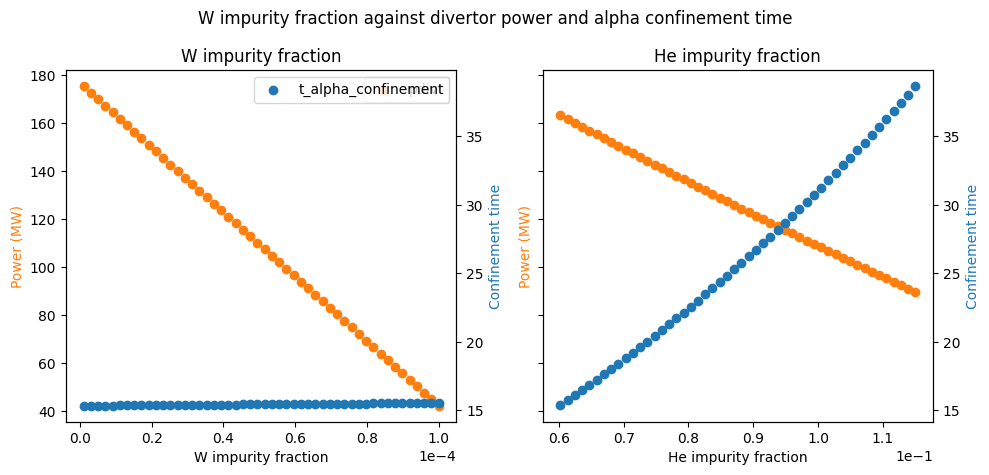

In [200]:
fig, ax = plt.subplots(ncols=2, sharey=True)
fig.set_figwidth(10)
ax01 = ax[0].twinx()
ax[0].scatter(w_imp_fracs, pdivt, label="pdivt", c="C1")
ax01.scatter(w_imp_fracs, t_alpha_confinement, c="C0", label="t_alpha_confinement")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("W impurity fraction")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)", color="C1")
ax01.set_ylabel("Confinement time", color="C0")
# Only showing one legend at the moment
ax[0].legend()
ax01.legend(loc=0)

ax11 = ax[1].twinx()
ax[1].scatter(he_imp_fracs, pdivt_he, label="pdivt", c="C1")
ax11.scatter(he_imp_fracs, t_alpha_confinement_he, c="C0", label="t_alpha_confinement")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].set_title("He impurity fraction")
ax[1].set_xlabel("He impurity fraction")
ax[1].set_ylabel("Power (MW)", color="C1")
ax11.set_ylabel("Confinement time", color="C0")

# Shared y axes
ax01.sharey(ax11)

fig.suptitle("W impurity fraction against divertor power and alpha confinement time")
fig.tight_layout()

As W and He fractions increase, pdivt drops. As W fraction increases, radiated power increases (not plotted, previous plots), causing this in the W plot. In the He plot, increasing He causes confinement time to increase, which appears to lead to reduced pdivt.

## What if pdivt were allowed to go negative?
Maths errors in the model currently prevent this, but what if this were allowed?

Text(1.5, -2.5, 'Violated')

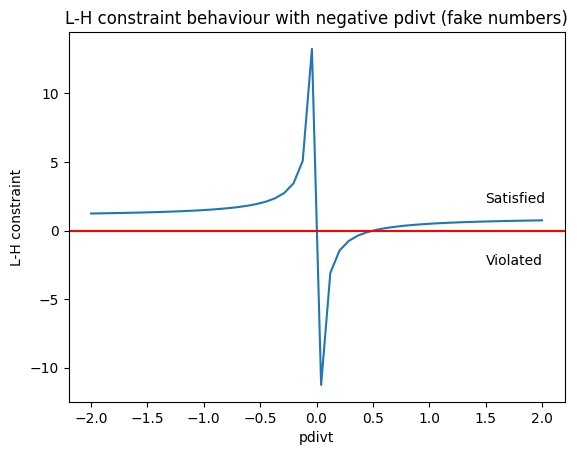

In [207]:
fig, ax = plt.subplots()
plhthresh = 0.5
pdivt = np.linspace(-2, 2, 50)
con = 1 - (plhthresh / pdivt)
ax.plot(pdivt, con)
ax.set_ylabel("L-H constraint")
ax.set_xlabel("pdivt")
ax.set_title("L-H constraint behaviour with negative pdivt (fake numbers)")
ax.axhline(0.0, color="r")
ax.annotate(
    "Satisfied",
    (1.5, 2.0),
)
ax.annotate(
    "Violated",
    (1.5, -2.5),
)

The constraint becomes incorrect: a negative pdivt would satisfy the constraint.

## Try to keep pdivt positive continuously

Current situation:

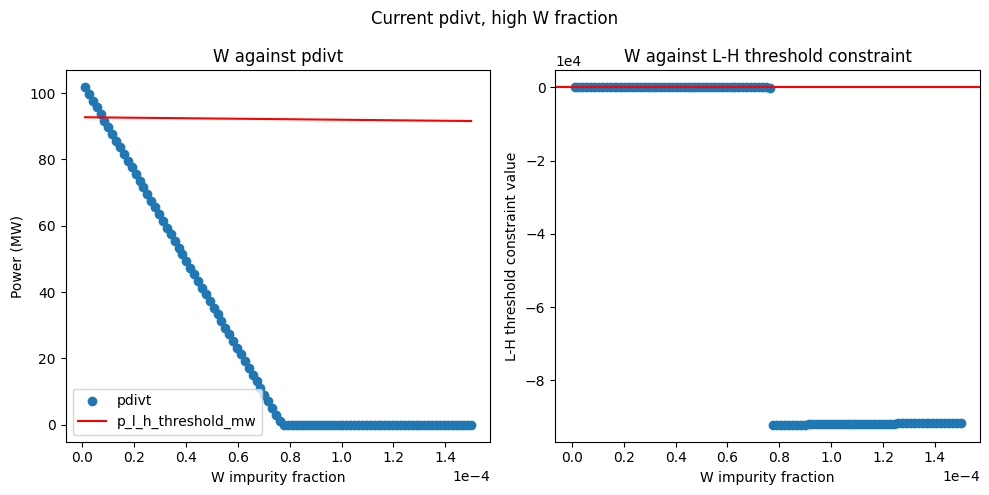

In [209]:
w_imp_fracs_high = np.linspace(1.0e-6, 1.5e-4, 100)
p_plasma_rad_mw, pdivt, p_l_h_threshold_mw, con15 = run_impurities(w_imp_fracs_high)

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# pdivt plot
ax[0].scatter(w_imp_fracs_high, pdivt, label="pdivt")
ax[0].plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("W against pdivt")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)")
ax[0].legend()
# Constraint plot
ax[1].scatter(w_imp_fracs_high, con15, label="con15")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax[1].set_title("W against L-H threshold constraint")
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("L-H threshold constraint value")
ax[1].axhline(0.0, color="r")

fig.suptitle("Current pdivt, high W fraction")
fig.tight_layout()

Want to keep a potentially negative pdivt positive (to keep the constraint valid) but also want to keep it linear (in proportion with other constraints).

Text(0.5, 1.0, 'Oblique and horizontal asymptote for y')

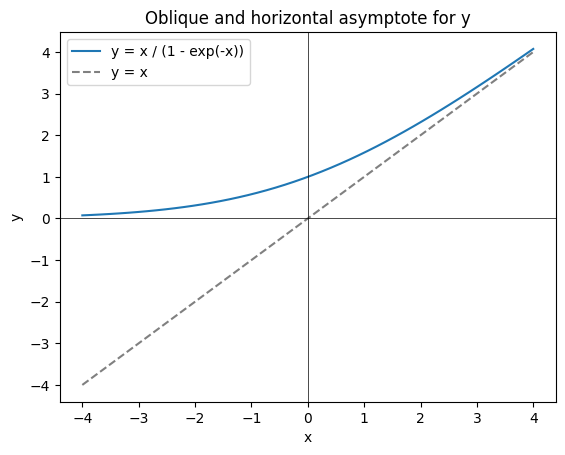

In [216]:
# TESTING
x_lim = 4
x = np.linspace(-x_lim, x_lim, 50)
y = x
# Try oblique asymptote
y2 = x / (1 - np.exp(-x))

fig, ax = plt.subplots()
ax.plot(x, y2, label="y = x / (1 - exp(-x))")
ax.plot(x, y, color="gray", label="y = x", ls="--")
ax.axhline(0.0, color="black", linewidth=0.5)
ax.axvline(0.0, color="black", linewidth=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Oblique and horizontal asymptote for y")

This has the right form.

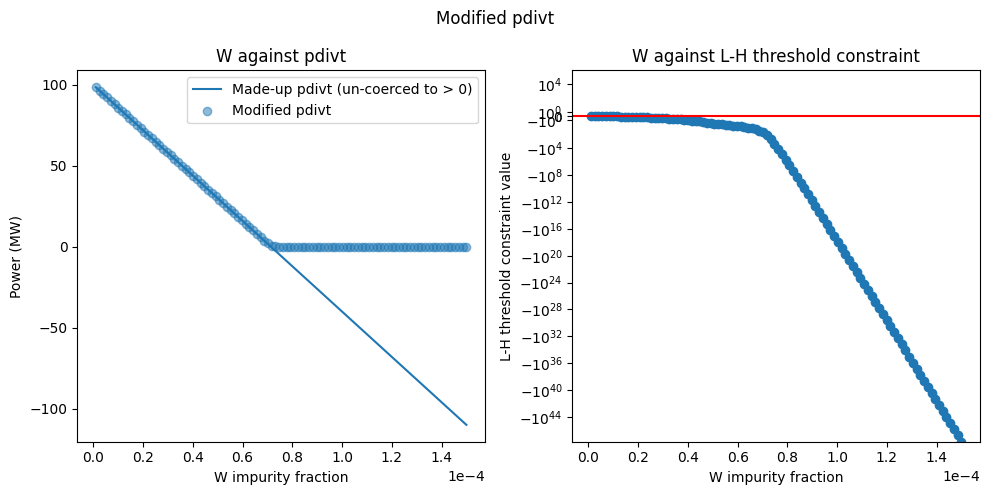

In [ ]:
# Re-create, but try to hold constraint positive
# Make non-positive coerced pdivt (as if Process model changed)
pdivt_neg = -(w_imp_fracs_high * 1.4e6) + 1e2
pdivt_pos = pdivt_neg * (np.exp(-pdivt_neg) + 1)
# Try out oblique asymptote modification
pdivt_pos = pdivt_neg / (1 - np.exp(-pdivt_neg))
con15_pos = 1 - p_l_h_threshold_mw / pdivt_pos

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# pdivt plot
ax[0].plot(w_imp_fracs_high, pdivt_neg, label="Made-up pdivt (un-coerced to > 0)")
ax[0].scatter(w_imp_fracs_high, pdivt_pos, label="Modified pdivt", alpha=0.5)
# ax[0].plot(w_imp_fracs_high, p_l_h_threshold_mw, "r", label="p_l_h_threshold_mw")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("W against pdivt")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)")
ax[0].legend()
# Constraint plot
ax[1].scatter(w_imp_fracs_high, con15_pos, label="con15")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax[1].set_title("W against L-H threshold constraint")
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("L-H threshold constraint value")
ax[1].axhline(0.0, color="r")
ax[1].set_yscale("symlog")
ax[1].set_ylim(ax[1].get_ylim()[0], 1e6)

fig.suptitle("Modified pdivt")
fig.tight_layout()

Now, despite a negative pdivt in the model, the constraint is continuous, monotonic and makes sense.

## What about something simpler?
Explore current constraint forms in Process.

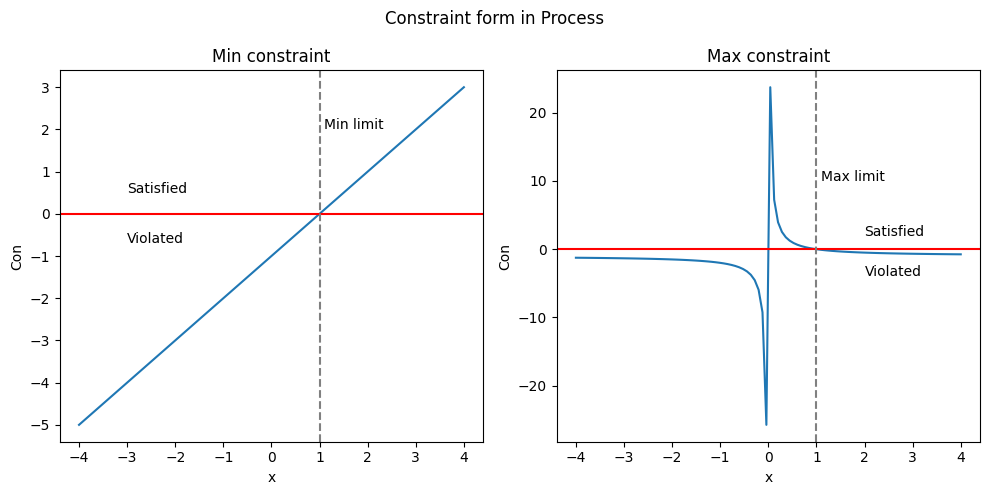

In [245]:
x_lim = 4
x = np.linspace(-x_lim, x_lim, 100)
x_max = 1
con_max = 1 - (x_max / x)
x_min = 1
con_min = 1 - (x / x_min)
# Flip signs to be same as process
con_max = -con_max
con_min = -con_min

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# x_max plot
ax[1].plot(x, con_max)
ax[1].set_title("Max constraint")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Con")
ax[1].axhline(0.0, color="r")
ax[1].axvline(x_max, color="gray", ls="--")
ax[1].annotate("Max limit", (1.1, 10.0))
ax[1].annotate(
    "Satisfied",
    (2, 2.0),
)
ax[1].annotate(
    "Violated",
    (2, -4.0),
)
# x_min plot
ax[0].plot(x, con_min)
ax[0].set_title("Min constraint")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Con")
ax[0].axhline(0.0, color="r")
ax[0].axvline(x_min, color="gray", ls="--")
ax[0].annotate("Min limit", (1.1, 2.0))
ax[0].annotate(
    "Satisfied",
    (-3, 0.5),
)
ax[0].annotate(
    "Violated",
    (-3, -0.7),
)
fig.suptitle("Constraint form in Process")
fig.tight_layout()

Max constraint form is nonlinear and hyperbolic. What about alternative form for max constraint?

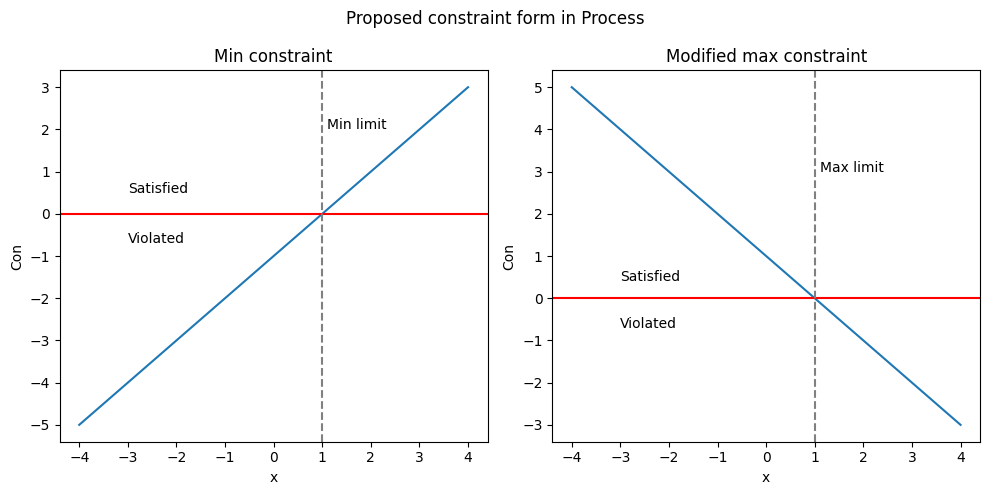

In [256]:
x_lim = 4
x = np.linspace(-x_lim, x_lim, 100)
x_max = 1
con_max = (x / x_max) - 1
x_min = 1
con_min = 1 - (x / x_min)
# Flip signs to be same as process
con_max = -con_max
con_min = -con_min

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# x_max plot
ax[1].plot(x, con_max)
ax[1].set_title("Modified max constraint")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Con")
ax[1].axhline(0.0, color="r")
ax[1].axvline(x_max, color="gray", ls="--")
ax[1].annotate("Max limit", (1.1, 3.0))
ax[1].annotate(
    "Satisfied",
    (-3, 0.4),
)
ax[1].annotate(
    "Violated",
    (-3, -0.7),
)
# x_min plot
ax[0].plot(x, con_min)
ax[0].set_title("Min constraint")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Con")
ax[0].axhline(0.0, color="r")
ax[0].axvline(x_min, color="gray", ls="--")
ax[0].annotate("Min limit", (1.1, 2.0))
ax[0].annotate(
    "Satisfied",
    (-3, 0.5),
)
ax[0].annotate(
    "Violated",
    (-3, -0.7),
)
fig.suptitle("Proposed constraint form in Process")
fig.tight_layout()

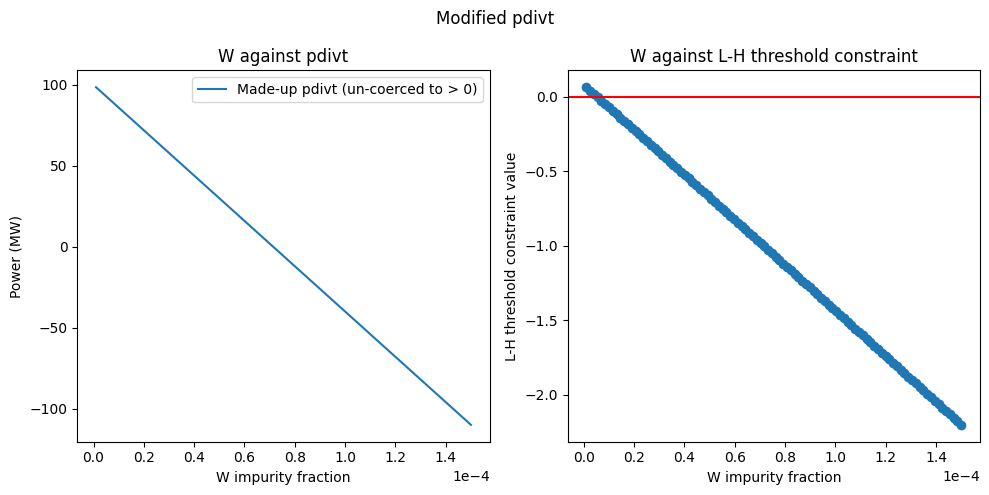

In [224]:
# Re-create, but try to hold constraint positive
# Make non-positive coerced pdivt (as if Process model changed)
pdivt_neg = -(w_imp_fracs_high * 1.4e6) + 1e2
# Try out oblique asymptote modification
# Original con
# con15_pos = 1 - p_l_h_threshold_mw / pdivt_neg
# New con
con15_pos = (pdivt_neg / p_l_h_threshold_mw) - 1

fig, ax = plt.subplots(ncols=2, sharex=True)
fig.set_figwidth(10)
fig.set_figheight(5)
# pdivt plot
ax[0].plot(w_imp_fracs_high, pdivt_neg, label="Made-up pdivt (un-coerced to > 0)")
ax[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0].set_title("W against pdivt")
ax[0].set_xlabel("W impurity fraction")
ax[0].set_ylabel("Power (MW)")
ax[0].legend()
# Constraint plot
ax[1].scatter(w_imp_fracs_high, con15_pos, label="con15")
ax[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax[1].set_title("W against L-H threshold constraint")
ax[1].set_xlabel("W impurity fraction")
ax[1].set_ylabel("L-H threshold constraint value")
ax[1].axhline(0.0, color="r")
# ax[1].set_yscale("symlog")
# ax[1].set_ylim(ax[1].get_ylim()[0], 1e6)

fig.suptitle("Modified pdivt")
fig.tight_layout()